# 07 — When does the structural prior fail?

Every result in this project rests on one bet: that writing the *right structure* into the model
beats learning it from data. EM-BP assumes the signal is a Markov chain, and because that
assumption is true of the data, it wins — by roughly an order of magnitude on pointwise score
error against networks with far more parameters.

Assumptions that are true are cheap to defend. The question that decides whether any of this
generalises is the opposite one: **what happens when the assumption is false?**

This was the project's largest acknowledged gap for months — the misspecification limitation was
stated in the paper and not addressed. It is now measured, across fifteen committed cells, and
the answer is not a single number. It depends entirely on *how* you break Markovianity.

## Two ways to not be a Markov chain

The experiment perturbs the generating process in two structurally different directions, both
parameterised so that $0$ recovers the exact chain.

**Rank-one contamination, strength $\beta$.** Add one shared latent to every site:

$$\tilde a_i = a_i + \beta\, \xi, \qquad \xi \sim \mathcal N(0,1)\ \text{drawn once per chain}$$

This genuinely breaks the Markov property — every pair of sites is now correlated through
$\xi$, however far apart — but it does so with a *single global* degree of freedom. At
$\beta = 1$ half the marginal variance is a shared constant.

**Long-range coupling, strength $\gamma$.** Add direct coupling between distant sites, so the
conditional independence structure itself is wrong: $a_i$ depends on $a_{i-k}$ for $k > 1$ in a
way no chain can represent.

The prediction, before looking: rank-one should be survivable, because a chain can partially
absorb a shared offset into its own correlation. Long-range coupling should not be, because it
puts dependence exactly where the chain asserts there is none.

In [1]:
import sys, csv, glob, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
ROOT = "../outputs/exp_21"

def load_cells():
    # exp_21 has two CSV schemas: gauss cells carry mechanism/strength, laplace carries beta.
    cells = {}
    for p in sorted(glob.glob(os.path.join(ROOT, "*", "nonmarkov_*.csv"))):
        name = os.path.basename(os.path.dirname(p))
        rows = list(csv.DictReader(open(p)))
        if not rows:
            continue
        if "mechanism" in rows[0]:
            mech, strength = rows[0]["mechanism"], float(rows[0]["strength"])
        else:
            mech, strength = "global", float(rows[0]["beta"])
        family = "laplace" if "laplace" in name else "gaussian"
        cells[name] = dict(family=family, mech=mech, strength=strength, rows=rows)
    return cells

cells = load_cells()
print(f"{len(cells)} committed cells")
for k, v in sorted(cells.items()):
    print(f"  {k:<18} family={v['family']:<8} mechanism={v['mech']:<10} "
          f"strength={v['strength']:<5} rows={len(v['rows'])}")

15 committed cells
  gauss_beta0.0      family=gaussian mechanism=global     strength=0.0   rows=15
  gauss_beta0.1      family=gaussian mechanism=global     strength=0.1   rows=15
  gauss_beta0.25     family=gaussian mechanism=global     strength=0.25  rows=15
  gauss_beta0.5      family=gaussian mechanism=global     strength=0.5   rows=15
  gauss_beta1.0      family=gaussian mechanism=global     strength=1.0   rows=15
  gauss_gamma0.0     family=gaussian mechanism=longrange  strength=0.0   rows=15
  gauss_gamma0.05    family=gaussian mechanism=longrange  strength=0.05  rows=15
  gauss_gamma0.1     family=gaussian mechanism=longrange  strength=0.1   rows=15
  gauss_gamma0.2     family=gaussian mechanism=longrange  strength=0.2   rows=15
  gauss_gamma0.4     family=gaussian mechanism=longrange  strength=0.4   rows=15
  laplace_beta0.0    family=laplace  mechanism=global     strength=0.0   rows=15
  laplace_beta0.1    family=laplace  mechanism=global     strength=0.1   rows=15
  laplace

## The metric

`ratio_to_em` is the arm's score error divided by EM-BP's, at matched noise level. Above 1 means
EM-BP is winning. Crossing 1 is the event of interest: it is the point where writing the wrong
structure into the model becomes worse than not writing any.

In [2]:
def ratio(cell, arm):
    v = [float(r["ratio_to_em"]) for r in cells[cell]["rows"] if r["arm"] == arm]
    return float(np.mean(v)) if v else np.nan

def fitted_rho(cell):
    v = [float(r["fitted_rho"]) for r in cells[cell]["rows"]
         if r["arm"] == "em_bp" and r.get("fitted_rho")]
    return float(np.mean(v)) if v else np.nan

def series(family, mech):
    sel = {k: v for k, v in cells.items() if v["family"] == family and v["mech"] == mech}
    ks = sorted(sel, key=lambda k: sel[k]["strength"])
    return ([sel[k]["strength"] for k in ks],
            [ratio(k, "cnn") for k in ks], [ratio(k, "mlp") for k in ks],
            [fitted_rho(k) for k in ks], ks)

for fam, mech, label in [("gaussian", "global", "rank-one  (beta)"),
                         ("gaussian", "longrange", "long-range (gamma)"),
                         ("laplace", "global", "rank-one, Laplace")]:
    s, c, m, fr, _ = series(fam, mech)
    print(f"\n{label}")
    print(f"  {'strength':>9}" + "".join(f"{x:>9.2f}" for x in s))
    print(f"  {'cnn/em':>9}" + "".join(f"{x:>9.2f}" for x in c))
    print(f"  {'mlp/em':>9}" + "".join(f"{x:>9.2f}" for x in m))
    print(f"  {'fitted rho':>9}" + "".join(f"{x:>9.3f}" for x in fr))


rank-one  (beta)
   strength     0.00     0.10     0.25     0.50     1.00
     cnn/em    10.76    31.47     8.27     3.44     2.43
     mlp/em    16.90    46.24    11.98     3.99     1.80
  fitted rho    0.849    0.850    0.862    0.889    0.938

long-range (gamma)
   strength     0.00     0.05     0.10     0.20     0.40
     cnn/em    20.94     1.24     1.03     0.85     0.76
     mlp/em    34.91     1.52     1.09     0.84     0.67
  fitted rho    0.851    0.821    0.808    0.787    0.742

rank-one, Laplace
   strength     0.00     0.10     0.25     0.50     1.00
     cnn/em     9.14     9.66     6.60     2.97     2.19
     mlp/em    13.54    16.31     9.30     3.59     1.84
  fitted rho    0.848    0.851    0.861    0.885    0.939


## The result

The prediction holds, and the asymmetry is stark.

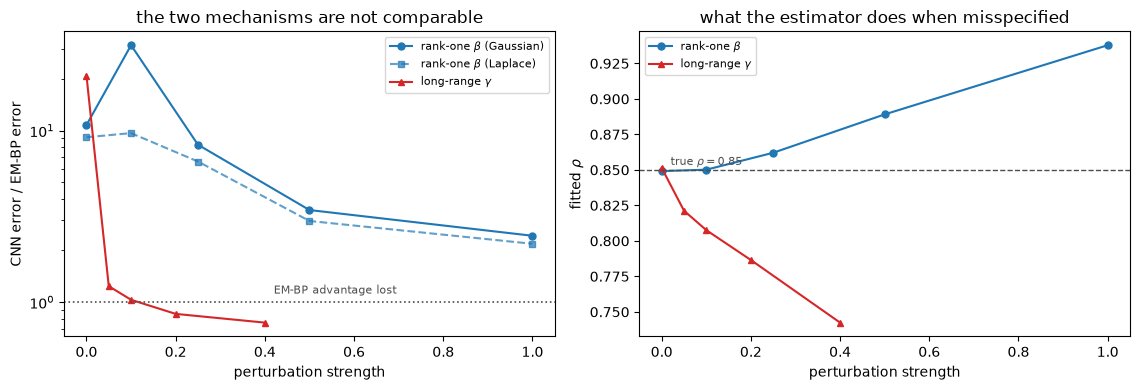

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.972 - 0.972))

s_b, c_b, m_b, _, _ = series("gaussian", "global")
s_g, c_g, m_g, _, _ = series("gaussian", "longrange")
s_l, c_l, m_l, _, _ = series("laplace", "global")

ax[0].plot(s_b, c_b, "C0-o", label="rank-one $\\beta$ (Gaussian)", ms=5)
ax[0].plot(s_l, c_l, "C0--s", label="rank-one $\\beta$ (Laplace)", ms=5, alpha=0.7)
ax[0].plot(s_g, c_g, "C3-^", label="long-range $\\gamma$", ms=5)
ax[0].axhline(1.0, color="0.3", ls=":", lw=1.2)
ax[0].text(0.42, 1.12, "EM-BP advantage lost", fontsize=8, color="0.3")
ax[0].set_yscale("log"); ax[0].set_xlabel("perturbation strength")
ax[0].set_ylabel("CNN error / EM-BP error")
ax[0].set_title("the two mechanisms are not comparable"); ax[0].legend(fontsize=8)

_, _, _, fr_b, _ = series("gaussian", "global")
_, _, _, fr_g, _ = series("gaussian", "longrange")
ax[1].plot(s_b, fr_b, "C0-o", label="rank-one $\\beta$", ms=5)
ax[1].plot(s_g, fr_g, "C3-^", label="long-range $\\gamma$", ms=5)
ax[1].axhline(0.85, color="0.3", ls="--", lw=1)
ax[1].text(0.02, 0.853, "true $\\rho = 0.85$", fontsize=8, color="0.3")
ax[1].set_xlabel("perturbation strength"); ax[1].set_ylabel("fitted $\\rho$")
ax[1].set_title("what the estimator does when misspecified"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Reading the right panel — the mechanism, not just the outcome

The fitted $\rho$ says what the estimator is *doing* when the model is wrong, and the two
mechanisms pull it in opposite directions.

- Under **rank-one contamination** $\rho$ climbs from $0.849$ toward $0.938$. The shared latent
  raises the correlation between every pair of sites, and the only way a chain can express "all
  sites are more correlated" is to raise $\rho$. The estimator is finding the best chain
  approximation to a non-chain — and paying for it in the coordinate it exists to estimate.

- Under **long-range coupling** $\rho$ *falls*, to $0.742$. Dependence has been moved out to
  distances the chain has no parameter for, so the nearest-neighbour correlation it can see is
  diluted. It is not absorbing the violation; it is being starved by it.

Both are misspecification. Only one is recoverable, and the fitted parameter tells you which
before the error metric does.

## How much can a single cell carry? — a caveat with a number on it

This sweep is **not paired across strengths**: each cell is an independent run with its own
seeds, so cell-to-cell scatter is real and must be bounded before any curve above is read too
closely.

There is a clean way to bound it. Two of the fifteen cells are *both* unperturbed controls —
`gauss_beta0.0` and `gauss_gamma0.0` are the same generating process at strength zero. Any
difference between them is pure run-to-run variance.

In [4]:
c0 = ratio("gauss_beta0.0", "cnn")
g0 = ratio("gauss_gamma0.0", "cnn")
print(f"  gauss_beta0.0   (control): cnn/em = {c0:6.2f}")
print(f"  gauss_gamma0.0  (control): cnn/em = {g0:6.2f}")
print(f"  ratio between two nominally identical cells: {max(c0,g0)/min(c0,g0):.2f}x\n")

b01 = ratio("gauss_beta0.1", "cnn")
print(f"  gauss_beta0.1            : cnn/em = {b01:6.2f}   "
      f"({b01/c0:.2f}x the beta control, {b01/g0:.2f}x the gamma control)")
for line in [
    "",
    "  So beta=0.1 sits high -- above BOTH controls -- and looks anomalous against the",
    "  smooth degradation the other beta cells show. But the two controls, which differ by",
    "  no more than their seeds, already span a factor of nearly two. An excursion of that",
    "  size is inside what this design can produce by chance, so beta=0.1 is not evidence",
    "  of a non-monotone effect. It is evidence that the sweep needs pairing before any",
    "  single cell is interpreted.",
]:
    print(line)

  gauss_beta0.0   (control): cnn/em =  10.76
  gauss_gamma0.0  (control): cnn/em =  20.94
  ratio between two nominally identical cells: 1.95x

  gauss_beta0.1            : cnn/em =  31.47   (2.92x the beta control, 1.50x the gamma control)

  So beta=0.1 sits high -- above BOTH controls -- and looks anomalous against the
  smooth degradation the other beta cells show. But the two controls, which differ by
  no more than their seeds, already span a factor of nearly two. An excursion of that
  size is inside what this design can produce by chance, so beta=0.1 is not evidence
  of a non-monotone effect. It is evidence that the sweep needs pairing before any
  single cell is interpreted.


That caveat cuts both ways, and it is worth being explicit about which conclusions survive it.

**Survives.** The long-range collapse is a factor of $\sim 20$ from control to $\gamma = 0.05$
and crosses $1.0$ — an order of magnitude beyond the $1.9\times$ control scatter, in a
consistent direction, at every strength, in both arms. And the *sign* of the $\rho$ drift is
opposite between mechanisms, which no amount of seed noise produces.

**Does not survive.** Any claim about the precise shape of the $\beta$ curve, the exact
crossover strength, or whether $\beta = 0.1$ means anything.

In [5]:
print("Where the advantage is lost (CNN ratio crossing 1.0):\n")
for fam, mech, lbl in [("gaussian","global","rank-one beta   "),
                       ("laplace","global","rank-one beta (L)"),
                       ("gaussian","longrange","long-range gamma")]:
    s, c, m, _, _ = series(fam, mech)
    below = [x for x, r in zip(s, c) if r < 1.0]
    if below:
        first = min(below)
        prev = max([x for x in s if x < first], default=None)
        print(f"  {lbl}: crosses between {prev} and {first}")
    else:
        print(f"  {lbl}: never crosses -- min ratio {min(c):.2f} at strength {s[int(np.argmin(c))]}")

Where the advantage is lost (CNN ratio crossing 1.0):

  rank-one beta   : never crosses -- min ratio 2.43 at strength 1.0
  rank-one beta (L): never crosses -- min ratio 2.19 at strength 1.0
  long-range gamma: crosses between 0.1 and 0.2


## What to take away

1. **Misspecification is not one thing.** The same nominal violation — "the data is not a Markov
   chain" — costs almost nothing in one direction and everything in another. Robustness claims
   about structural priors are meaningless without saying *along which axis*.

2. **Rank-one contamination is survivable.** Up to $\beta = 1.0$, where half the marginal
   variance is a shared constant, EM-BP still leads both networks. A chain can absorb a global
   offset by inflating $\rho$ — badly, but usefully.

3. **Long-range coupling is fatal, and quickly.** The advantage is gone by $\gamma \approx 0.1$
   — a perturbation far smaller than the rank-one one it tolerates. This is the honest boundary
   of the method, and it should be stated as such rather than as a generic caveat.

4. **The fitted parameter diagnoses the failure before the error does.** $\rho$ drifting *up*
   means the estimator is absorbing the violation; drifting *down* means it is being starved by
   it. That is available at fit time, without a ground-truth score to compare against — which is
   the only situation you are ever in on real data.

*Sources: `outputs/exp_21/{gauss,laplace}_{beta,gamma}*/nonmarkov_*.csv`, fifteen cells.
Caveat on pairing is the experiment's own, quantified here against the two zero-strength
controls.*